In [1]:
import os
import math
import random
import numpy as np
import torch

import rasterio
from rasterio.windows import Window
from utils import read_and_normalize_s2, get_sample_locations
from datetime import datetime
import math
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt



In [102]:
class BuildingBinaryRaster(Dataset):
    """
    Dataset for co-registered binary building segmentation from mbf_binry.tif.
    - Assumes identical CRS/transform/shape to the Sentinel-2 tiles.
    - Uses the same px1/px2 exclusion and (160->128) window/crop as before.
    - Returns:
        s2data: (C,128,128) float in [0,1]
        label:  (128,128) float with values {0.0, 1.0}
    """
    def __init__(self,
                 top_dir,
                 s2_tiles,
                 labels,
                 training_bounds_left_top_right_bottom,
                 train_val_key,
                 complete_tile_size,
                 exclude_px1_px2,
                 patch_size=128,
                 buffer=32):

        self.top_dir = top_dir
        self.s2_tiles = s2_tiles
        self.labels = labels
        self.train_val_key = train_val_key
        self.patch_size = patch_size
        self.buffer = buffer

        locations = get_sample_locations(
            10980, 
            tb=training_bounds_left_top_right_bottom, 
            train_val_key=self.train_val_key,
            patch_size=patch_size,
            exclude_px1_px2=exclude_px1_px2
            )


        self.samples = []
        for loc in tqdm(locations, desc=f"Building {train_val_key} samples"):
            for sample_idx, time_str in enumerate(s2_tiles):
                # print(time_str)
                if "BF" not in time_str:
                    self.samples.append({
                        "sample_idx": int(sample_idx),
                        "time_str": time_str,
                        "location": loc
                    })
                else: continue

        np.random.shuffle(self.samples)
        print(f"{len(self.samples)} {train_val_key} samples after exclusion")

    def _get_dt_properties(self, time_str):

        capture_time = os.path.splitext(os.path.basename(time_str))[0]
        dt = datetime.strptime(capture_time, "%Y%m%dT%H%M%S")

        t0 = datetime(2015, 1, 1)
        delta = (dt - t0).total_seconds() / 86400.0  # days since t0

        # day-of-year
        doy = dt.timetuple().tm_yday  # 1..365/366
        doy_norm = (doy - 1) / 365.0
        doy_sin = math.sin(2 * math.pi * doy_norm)
        doy_cos = math.cos(2 * math.pi * doy_norm)

        return {"file_name": time_str,"delta_days": delta, "doy_sin": doy_sin, "doy_cos": doy_cos,}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        dt_properties = self._get_dt_properties(s["time_str"])
        if self.train_val_key == "val":
            y_off, x_off = 16, 16
        else:
            y_off = np.random.randint(0, self.buffer + 1)
            x_off = np.random.randint(0, self.buffer + 1)

        s2_path = os.path.join(self.top_dir, self.s2_tiles[s["sample_idx"]])
        # ---- Read Sentinel-2 raster window & crop ----
        img = read_and_normalize_s2(
            s2_path,
            s,
            x_off,
            y_off,
            self.patch_size,
            win_size=160
        )

        # The labels are in 2.5 meter gsd, so need to scale the window by 4x
        # --- read binary mask window & crop (already aligned) ---
        with rasterio.open(os.path.join(self.top_dir, self.labels)) as src:
            win = Window(s["location"][1]*4, s["location"][0]*4, 160*4, 160*4)
            label = src.read(1, window=win)
            label = label[y_off*4:y_off*4 + self.patch_size*4, x_off*4:x_off*4 + self.patch_size*4]
        label = torch.from_numpy(label).long()  # (128,128) {0.0, 1.0}

        return {
            "timestamp": torch.tensor(dt_properties["delta_days"], dtype=torch.float32),
            "time_str": s["time_str"],
            "x_s2": x_off + s["location"][1],
            "y_s2": y_off + s["location"][0],
            "s2data": img,
            "label": label
        }


In [2]:
class BuildingBinaryRaster(Dataset):
    """
    Dataset for co-registered binary building segmentation from mbf_binry.tif.
    - Assumes identical CRS/transform/shape to the Sentinel-2 tiles.
    - Uses the same px1/px2 exclusion and (160->128) window/crop as before.
    - Returns:
        s2data: (C,128,128) float in [0,1]
        label:  (128,128) float with values {0.0, 1.0}
    """
    def __init__(self,
                 top_dir,
                 s2_tiles,
                 labels,
                 training_bounds_left_top_right_bottom,
                 train_val_key,
                 complete_tile_size,
                 exclude_px1_px2,
                 patch_size=128,
                 buffer=32):

        self.top_dir = top_dir
        self.s2_tiles = s2_tiles
        self.labels = labels
        self.train_val_key = train_val_key
        self.patch_size = patch_size
        self.buffer = buffer

        locations = get_sample_locations(
            10980, 
            tb=training_bounds_left_top_right_bottom, 
            train_val_key=self.train_val_key,
            patch_size=patch_size,
            exclude_px1_px2=exclude_px1_px2
            )


        # self.samples = []
        # for loc in tqdm(locations, desc=f"Building {train_val_key} samples"):
        #     for sample_idx, time_str in enumerate(s2_tiles):
        #         # print(time_str)
        #         if "BF" not in time_str:
        #             self.samples.append({
        #                 "sample_idx": int(sample_idx),
        #                 "time_str": time_str,
        #                 "location": loc
        #             })
        #         else: continue

        self.min_building_frac = 0.010  # 1%
        self.win_size = 160            # the "big" window before 128 crop
        self.scale = 4                 # label resolution is 4x finer than S2 grid

        # --- replace your current self.samples building loop with this ---
        self.samples = []
        kept_locs = 0
        skipped_locs = 0

        # Open label raster once (much faster than opening for every loc)
        with rasterio.open(os.path.join(self.top_dir, self.labels)) as src_lbl:
            for loc in tqdm(locations, desc=f"Building {train_val_key} samples"):

                # read label window corresponding to the 160x160 S2 window (scaled to label gsd)
                win_lbl = Window(loc[1] * self.scale, loc[0] * self.scale,
                                self.win_size * self.scale, self.win_size * self.scale)

                lbl = src_lbl.read(1, window=win_lbl)

                # Compute building fraction in this window.
                # If lbl is {0,1} (or {0,255}), adapt accordingly:
                if lbl.dtype != np.bool_:
                    # Common cases:
                    # - 0/1 integer mask: mean gives fraction
                    # - 0/255 uint8 mask: (lbl > 0).mean gives fraction
                    building_frac = (lbl > 0).mean()
                else:
                    building_frac = lbl.mean()

                if building_frac <= self.min_building_frac:
                    skipped_locs += 1
                    continue

                kept_locs += 1

                # Only now expand across time / seasons
                for sample_idx, time_str in enumerate(s2_tiles):
                    if "BF" in time_str:
                        continue
                    self.samples.append({
                        "sample_idx": int(sample_idx),
                        "time_str": time_str,
                        "location": loc,
                        "building_frac_160": float(building_frac),  # optional, helpful for debugging
                    })

        np.random.shuffle(self.samples)
        print(f"Kept {kept_locs}/{kept_locs + skipped_locs} locations with >{int(self.min_building_frac*100)}% buildings")
        print(f"{len(self.samples)} {train_val_key} samples after exclusion + building filter")

        np.random.shuffle(self.samples)
        print(f"{len(self.samples)} {train_val_key} samples after exclusion")

    def _get_dt_properties(self, time_str):

        capture_time = os.path.splitext(os.path.basename(time_str))[0]
        dt = datetime.strptime(capture_time, "%Y%m%dT%H%M%S")

        t0 = datetime(2015, 1, 1)
        delta = (dt - t0).total_seconds() / 86400.0  # days since t0

        # day-of-year
        doy = dt.timetuple().tm_yday  # 1..365/366
        doy_norm = (doy - 1) / 365.0
        doy_sin = math.sin(2 * math.pi * doy_norm)
        doy_cos = math.cos(2 * math.pi * doy_norm)

        return {"file_name": time_str,"delta_days": delta, "doy_sin": doy_sin, "doy_cos": doy_cos,}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        dt_properties = self._get_dt_properties(s["time_str"])
        if self.train_val_key == "val":
            y_off, x_off = 16, 16
        else:
            y_off = np.random.randint(0, self.buffer + 1)
            x_off = np.random.randint(0, self.buffer + 1)

        s2_path = os.path.join(self.top_dir, self.s2_tiles[s["sample_idx"]])
        # ---- Read Sentinel-2 raster window & crop ----
        img = read_and_normalize_s2(
            s2_path,
            s,
            x_off,
            y_off,
            self.patch_size,
            win_size=160
        )

        # The labels are in 2.5 meter gsd, so need to scale the window by 4x
        # --- read binary mask window & crop (already aligned) ---
        with rasterio.open(os.path.join(self.top_dir, self.labels)) as src:
            win = Window(s["location"][1]*4, s["location"][0]*4, 160*4, 160*4)
            label = src.read(1, window=win)
            label = label[y_off*4:y_off*4 + self.patch_size*4, x_off*4:x_off*4 + self.patch_size*4]
        label = torch.from_numpy(label).long()  # (512,512) {0.0, 1.0}

        return {
            "timestamp": torch.tensor(dt_properties["delta_days"], dtype=torch.float32),
            "time_str": s["time_str"],
            "x_s2": x_off + s["location"][1],
            "y_s2": y_off + s["location"][0],
            "s2data": img,
            "label": label
        }

In [3]:
# px1 = (0, 4800) # We lack labels for this area, so we exclude it from training/validation
# px2 = (3040, 6080)

ds_train = BuildingBinaryRaster(
    top_dir="/home/user/data_shared/T16TEK/",
    s2_tiles=['20221108T163511.tif', '20250814T162921.tif', '20251122T163621.tif', '20221009T163211.tif', '20220914T162839.tif', '20240918T162941.tif', '20240829T162901.tif', '20240211T163421.tif', '20231118T163549.tif', '20250518T163701.tif', '20250918T162839.tif', '20220107T163649.tif', '20240226T163139.tif', '20220721T162851.tif', '20230517T162831.tif', '20221029T163421.tif', '20221203T163649.tif', '20220507T162829.tif', '20250928T162949.tif', '20240406T162829.tif', '20230914T162911.tif', '20221004T163129.tif', '20240824T162829.tif', '20230412T162839.tif', '20220427T162829.tif', '20230924T163021.tif', '20241008T163201.tif', '20220621T162911.tif', '20250908T162829.tif', '20220313T163051.tif', '20250610T162829.tif', '20240725T162839.tif', '20221103T163439.tif', '20250915T163701.tif', '20231123T163611.tif', '20250225T163301.tif', '20241003T163029.tif', '20230711T162839.tif', '20231113T163531.tif', '20221014T163229.tif', '20241018T163311.tif', '20221019T163311.tif', '20230211T163419.tif'],
    labels="BF_20250928T162949_20250928T162949_2.5m.tif",
    training_bounds_left_top_right_bottom=[4000, 0, 5000, 5000],
    train_val_key="val",
    complete_tile_size=10980,
    exclude_px1_px2=None,
    patch_size=128,
    buffer=32
)

Building val samples:   0%|          | 0/4400 [00:00<?, ?it/s]

Kept 1157/4400 locations with >1% buildings
49751 val samples after exclusion + building filter
49751 val samples after exclusion


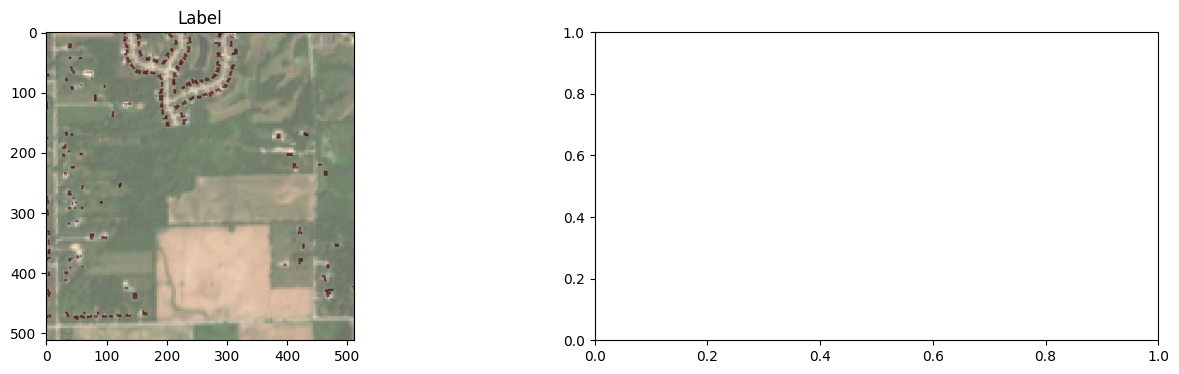

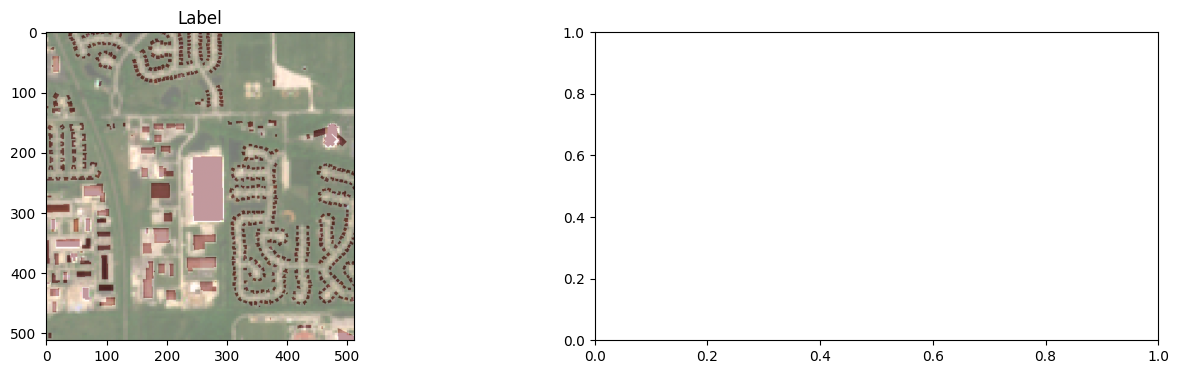

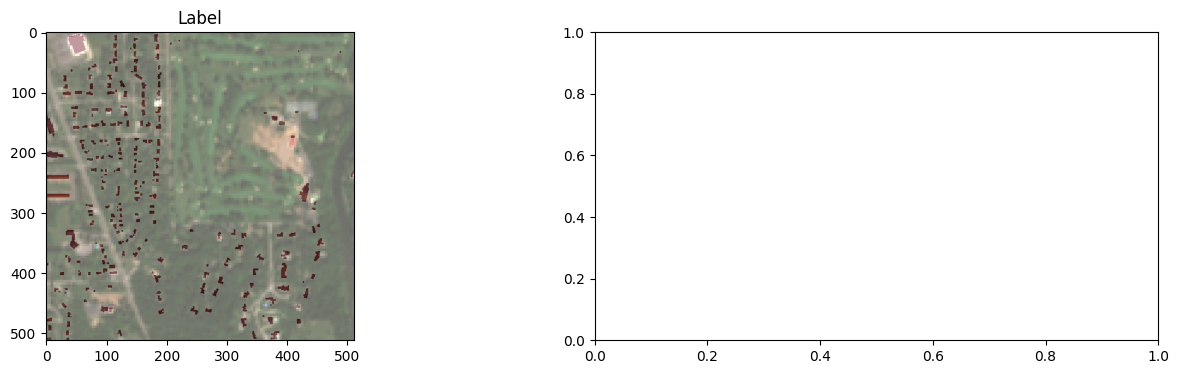

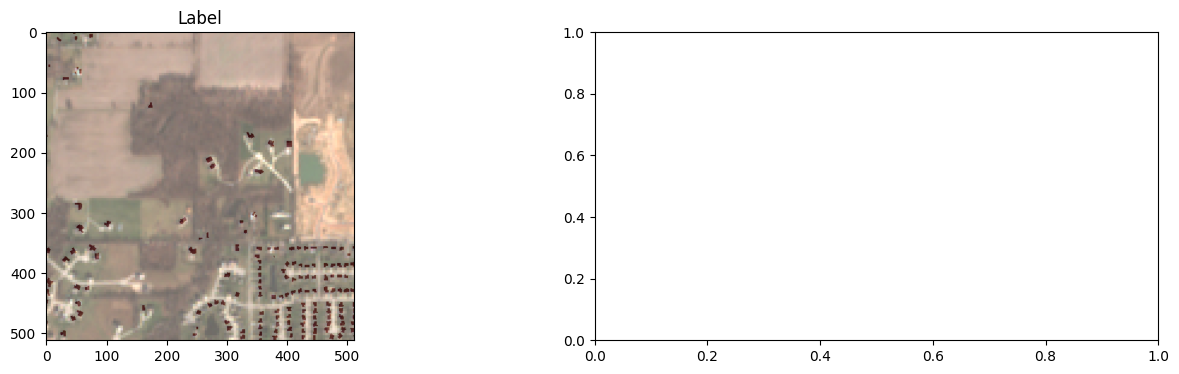

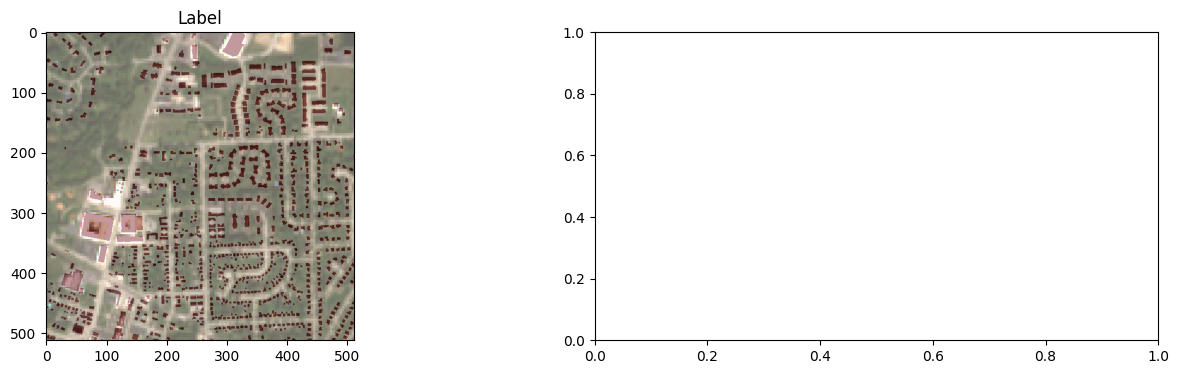

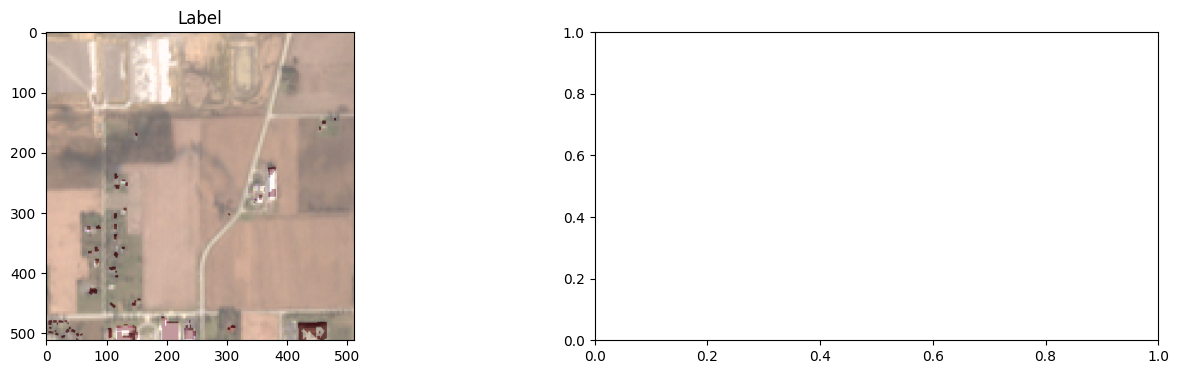

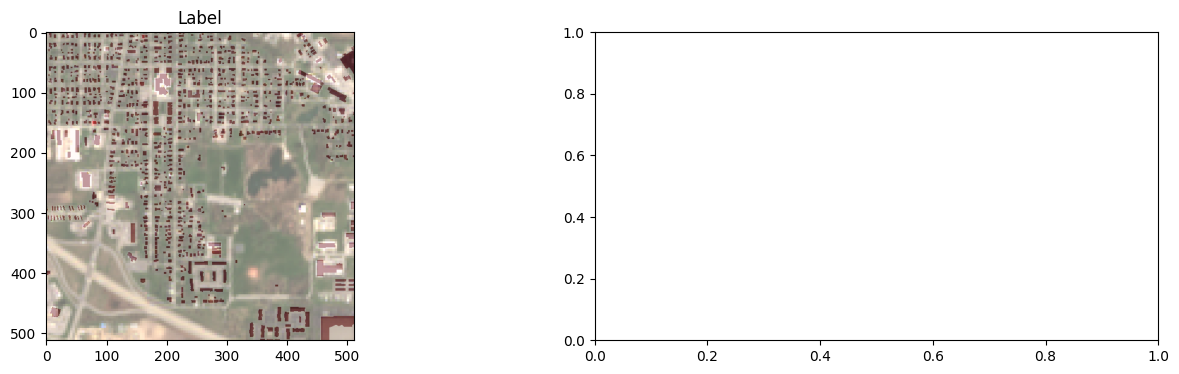

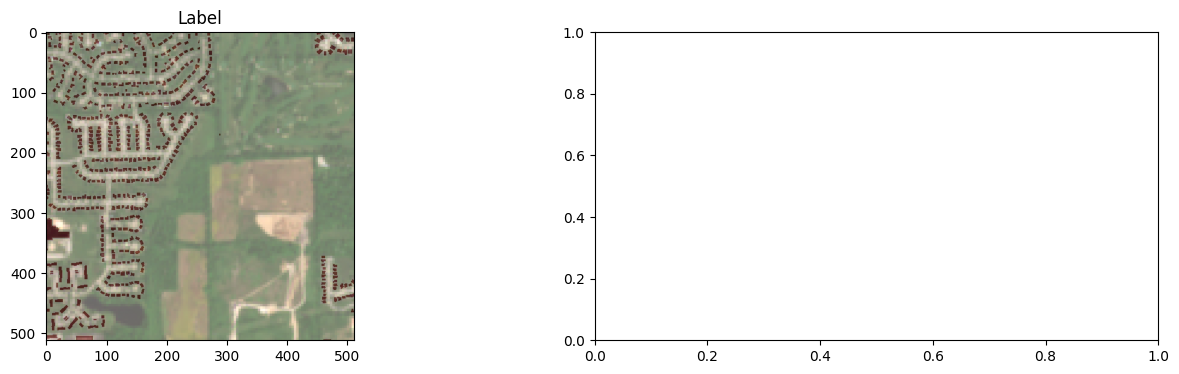

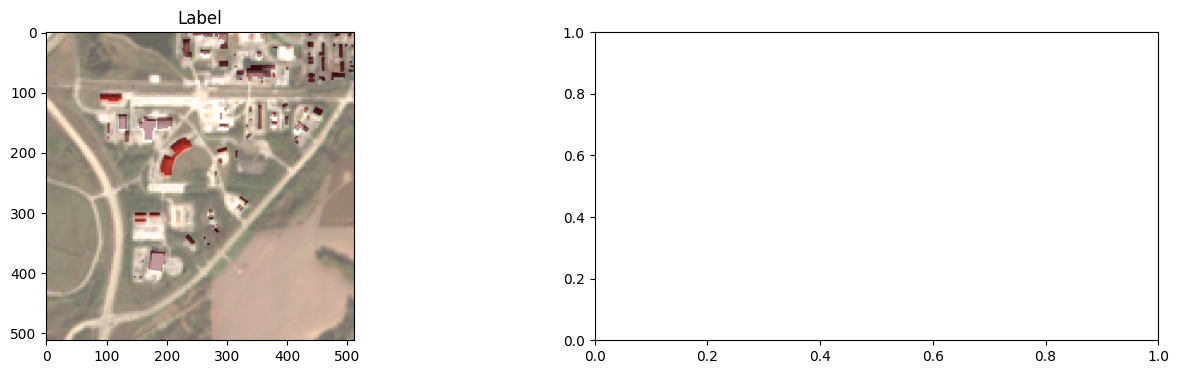

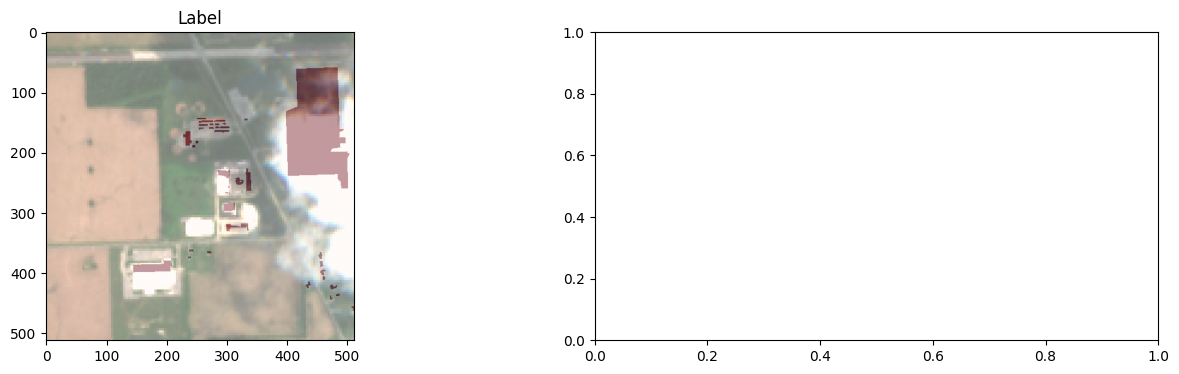

In [5]:
import matplotlib.pyplot as plt
from utils import s2_to_rgb

scale = 4

for i in [1000,1500,2000,2500,2800,3000,3500,4000,4500,5000]:
    img = ds_train[i]["s2data"].numpy()
    label = ds_train[i]["label"].numpy()
    fig, axs = plt.subplots(1, 2, figsize=(16, 4))
    rgb_img = s2_to_rgb(img)
    arr512 = np.repeat(np.repeat(rgb_img, scale, axis=0), scale, axis=1)
    axs[0].imshow(arr512)
    axs[0].set_title("S2 RGB")
    axs[0].imshow(label, vmin=0, vmax=1, alpha=0.4, cmap='Reds')
    axs[0].set_title("Label")
    cmap = plt.get_cmap('gray')
    vvmin, vvmax = 0, 1

In [64]:
with rasterio.open("/home/user/data_shared/T16TEK/BF_20250928T162949_20250928T162949_2.5m.tif") as src:
    img = src.read(1)

with rasterio.open("/home/user/data_shared/T16TEK/20250928T162949.tif") as src:
    s2_img = src.read()
    s2_img = np.clip((s2_img - 1000) / 10000.0, 0, 1)


Text(0.5, 1.0, 'Label')

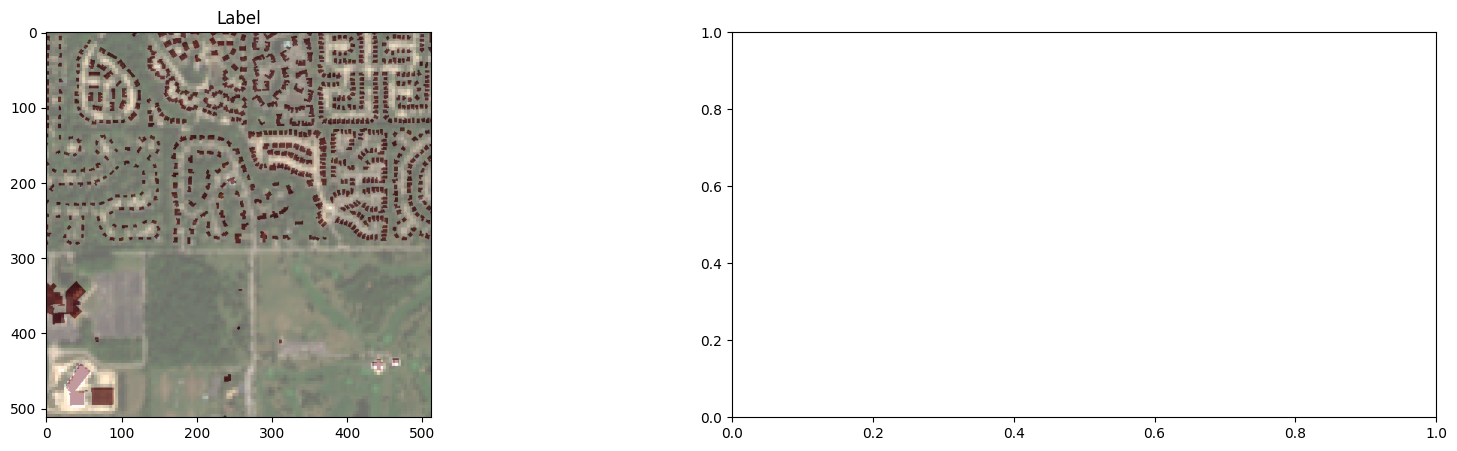

In [70]:
y = 8000
x = 8000
label = img[y*4:y*4+512, x*4:x*4+512]
s2_img_norm = s2_img[:, y:y+128, x:x+128]
scale = 4
arr512 = np.repeat(np.repeat(s2_img_norm, scale, axis=1), scale, axis=2)


fig, axs = plt.subplots(1, 2, figsize=(20, 5))
arr512 = s2_to_rgb(arr512)
axs[0].imshow(arr512)
axs[0].set_title("S2 RGB")
axs[0].imshow(label, vmin=0, vmax=1, alpha=0.4, cmap='Reds')
axs[0].set_title("Label")

In [43]:
y4

111